In [1]:
'''
This script takes a collection of images as input, then uses feature detection to 
track the object's motion between frames. By tracking the features, and having the 
knowledge of how much the object rotated, we can perform a 3D reconstruction of the
object.

To get SURF, make sure to run:
pip install opencv-contrib-python
'''

#%pip install ipympl

#%matplotlib widget
#%matplotlib notebook
#%matplotlib ipympl

# Imports
import sys
import time
import copy
import numpy as np
import cv2 as cv
import glob
from matplotlib import pylab as plt
from math import pi, sqrt
import math

import pandas as pd

#  On the mac, cv2 has a problem importing.
#  Edit this file:  /usr/local/lib/python3.10/site-packages/cv2/typing/__init__.py
#  


#-------------------------------------------------------------------------------
#                                   show_image
#-------------------------------------------------------------------------------
def show_image(title, opencvImage):
    
    plt.figure()
    # OpenCV stores images in BGR order instead of RGB, so convert
    plt.imshow(cv.cvtColor(opencvImage, cv.COLOR_BGR2RGB))
    plt.title(title)

    return


# Load Images

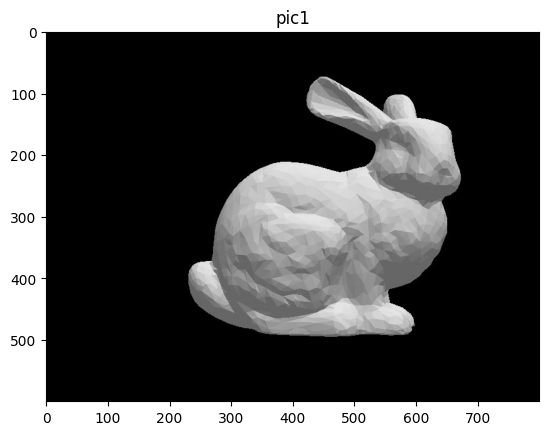

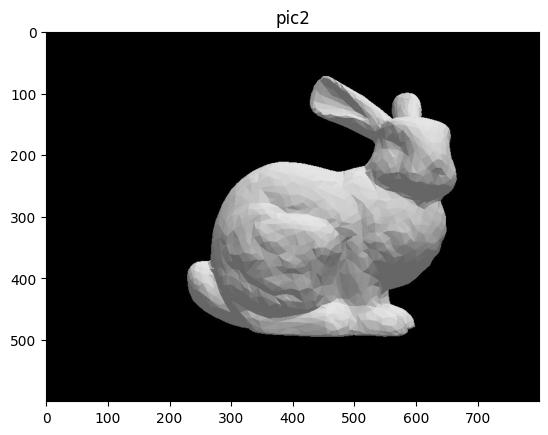

In [2]:
# Load two images, separated by a 5 degree rotation
#pic1 = cv.imread('/Users/jrp/Dropbox (Meta)/Jupyter/Crystal_Rotation/bunny_pics/Bunny_ 360deg.jpg')
pic1 = cv.imread('bunny_pics/Bunny_ 000deg.jpg')
show_image('pic1', pic1)

#pic2 = cv.imread('/Users/jrp/Dropbox (Meta)/Jupyter/Crystal_Rotation/bunny_pics/Bunny_ 005deg.jpg')
pic2 = cv.imread('bunny_pics/Bunny_ 005deg.jpg')
show_image('pic2', pic2)

# Extract Features

"\nnumFeatures = 10000   # default = 500\nscaleFactor = 1      # default = 1.2 (lower = slower)\nnumLevels = 32       # default = 8\nsizeThreshold = 7    # default = 31  (applies to edgeThreshold and patchSize)\n\npic1_orb = cv.ORB_create(nfeatures=numFeatures, scaleFactor=scaleFactor, nlevels=numLevels, edgeThreshold=sizeThreshold, patchSize=sizeThreshold)\npic1_kp, pic1_desc = pic1_orb.detectAndCompute(pic1_gray, None)\npic1_features = cv.drawKeypoints(pic1, pic1_kp, None)\nshow_image('pic1 keypoints', pic1_features)\n\npic2_orb = cv.ORB_create(nfeatures=numFeatures, scaleFactor=scaleFactor, nlevels=numLevels, edgeThreshold=sizeThreshold, patchSize=sizeThreshold)\npic2_kp, pic2_desc = pic2_orb.detectAndCompute(pic2_gray, None)\npic2_features = cv.drawKeypoints(pic2, pic2_kp, None)\nshow_image('pic2 keypoints', pic2_features)\n"

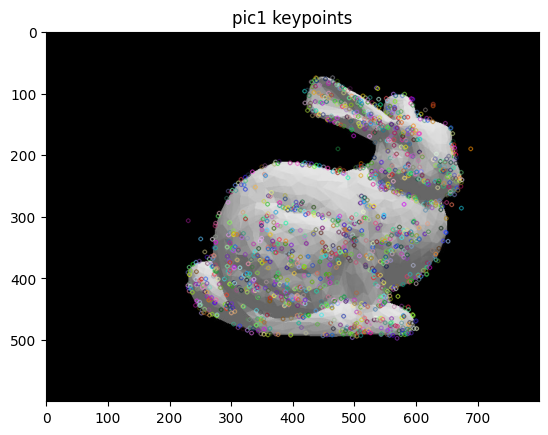

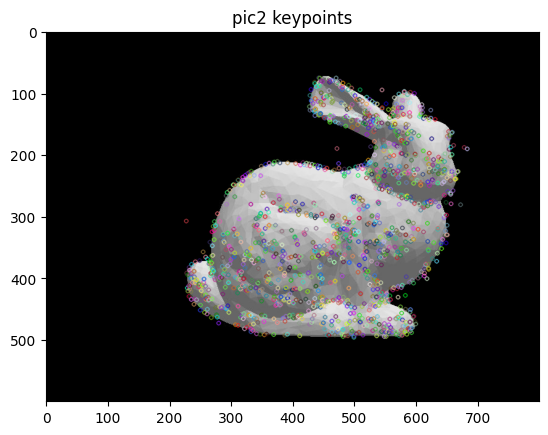

In [3]:
#%pip install opencv-contrib-python

# Convert to grayscale
pic1_gray = cv.cvtColor(pic1, cv.COLOR_BGR2GRAY)
pic2_gray = cv.cvtColor(pic2, cv.COLOR_BGR2GRAY)

# use SIFT to detect features:  https://docs.opencv.org/3.4/d7/d60/classcv_1_1SIFT.html
numFeatures = 10000         # default = 0
numOctaveLayers = 75        # default = 3.  Higher numbers seem to increase the number of detected features
contrastThreshold = 0.04    # default = 0.04
edgeThreshold = 10          # default = 10
sigma = 1.6                 # default = 1.6

pic1_sift = cv.SIFT_create(nfeatures=numFeatures, nOctaveLayers=numOctaveLayers, contrastThreshold=contrastThreshold, edgeThreshold=edgeThreshold, sigma=sigma)
pic1_kp, pic1_desc = pic1_sift.detectAndCompute(pic1_gray, None)
pic1_features = cv.drawKeypoints(pic1, pic1_kp, None)
show_image('pic1 keypoints', pic1_features)

pic2_sift = cv.SIFT_create(nfeatures=numFeatures, nOctaveLayers=numOctaveLayers, contrastThreshold=contrastThreshold, edgeThreshold=edgeThreshold, sigma=sigma)
pic2_kp, pic2_desc = pic2_sift.detectAndCompute(pic2_gray, None)
pic2_features = cv.drawKeypoints(pic2, pic2_kp, None)
show_image('pic2 keypoints', pic2_features)


# Use ORB to detect features:  https://docs.opencv.org/4.x/db/d95/classcv_1_1ORB.html#aeff0cbe668659b7ca14bb85ff1c4073b
'''
numFeatures = 10000   # default = 500
scaleFactor = 1      # default = 1.2 (lower = slower)
numLevels = 32       # default = 8
sizeThreshold = 7    # default = 31  (applies to edgeThreshold and patchSize)

pic1_orb = cv.ORB_create(nfeatures=numFeatures, scaleFactor=scaleFactor, nlevels=numLevels, edgeThreshold=sizeThreshold, patchSize=sizeThreshold)
pic1_kp, pic1_desc = pic1_orb.detectAndCompute(pic1_gray, None)
pic1_features = cv.drawKeypoints(pic1, pic1_kp, None)
show_image('pic1 keypoints', pic1_features)

pic2_orb = cv.ORB_create(nfeatures=numFeatures, scaleFactor=scaleFactor, nlevels=numLevels, edgeThreshold=sizeThreshold, patchSize=sizeThreshold)
pic2_kp, pic2_desc = pic2_orb.detectAndCompute(pic2_gray, None)
pic2_features = cv.drawKeypoints(pic2, pic2_kp, None)
show_image('pic2 keypoints', pic2_features)
'''

# Match Detected Features

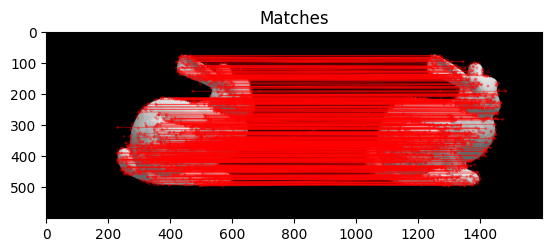

In [4]:
# https://docs.opencv.org/4.x/dc/dc3/tutorial_py_matcher.html

# FLANN parameters (SIFT)
FLANN_INDEX_KDTREE = 1
index_params = dict(algorithm = FLANN_INDEX_KDTREE, trees = 5)

# FLANN parameteters (ORB)
'''
FLANN_INDEX_LSH = 6
index_params= dict(algorithm = FLANN_INDEX_LSH,
                   table_number = 6, # 12
                   key_size = 12, # 20
                   multi_probe_level = 1) #2
'''

search_params = dict(checks=100) # or pass empty dictionarys

flann = cv.FlannBasedMatcher(index_params, search_params)

matches = flann.knnMatch(pic1_desc, pic2_desc, k=2)

# Need to draw only good matches, so create a mask
matchesMask = [[0,0] for i in range(len(matches))]

# ratio test as per Lowe's paper
for i,(m,n) in enumerate(matches):
    if m.distance < 0.7*n.distance:    # <--- This threshold impacts the results. Investigate it.
        matchesMask[i]=[1,0]

draw_params = dict(matchColor = (0,0,255), 
                   singlePointColor = (0,0,255),
                   matchesMask = matchesMask,
                   flags = cv.DrawMatchesFlags_DEFAULT)

match_image = cv.drawMatchesKnn(pic1, pic1_kp, pic2, pic2_kp, matches, None, **draw_params)
show_image('Matches', match_image)

# Review Matches

Found 700 good matches...
Removed 118...


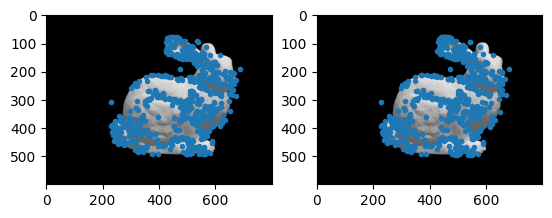

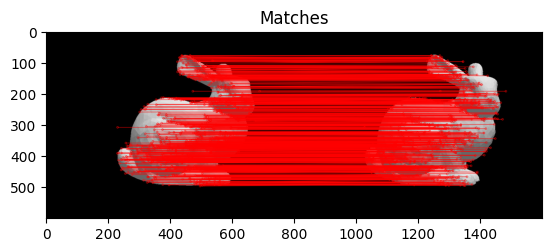

In [52]:
# https://docs.opencv.org/4.x/d4/de0/classcv_1_1DMatch.html


# Get the size of the images (they are the same)
h,w = np.shape(pic1_gray)

def dist(pt1, pt2):
    x1 = pt1[0]
    y1 = pt1[1]

    x2 = pt2[0]
    y2 = pt2[1]

    d = sqrt((x1-x2)**2 + (y2-y1)**2)
    return d


def y_dist(pt1, pt2):
    return abs(pt2[1] - pt1[1])



yMovementThreshold = 10
xyMinMovementThreshold = 0

#yMovementThreshold = .1
#xyMinMovementThreshold = 0   # Minimim number of pixels a coordinate should have moved (distance)
x1 = []
y1 = []
x2 = []
y2 = []


# Need to draw only good matches, so create a mask
matchesMask = [[0,0] for i in range(len(matches))]
goodMatches = 0
good = []
distances = []

for i,(m,n) in enumerate(matches):
    # This is the "hamming distance"
    if m.distance < 0.7*n.distance:    # <--- This threshold impacts the results. Investigate it.
        # The match is good
        index1 = m.queryIdx
        index2 = m.trainIdx

        try:
            pt1 = pic1_kp[index1].pt
            pt2 = pic2_kp[index2].pt
        except:
            print(index1, index2)
            continue

        # The y-distance shouldn't have moved.  Compare it and see how close it is.
        if y_dist(pt1, pt2) < yMovementThreshold:
            
            # Find the total distance the pixel moved
            d = dist(pt1, pt2)

            distances.append(d)

            if d >= xyMinMovementThreshold:

                # The points should be valid...
                x1.append(pt1[0])
                y1.append(pt1[1])

                x2.append(pt2[0])
                y2.append(pt2[1])

                # Keep track of the good matches
                matchesMask[i]=[1,0]
                goodMatches += 1

                good.append(m)
                

print(f'Found {goodMatches} good matches...')

# Compute the mean & standard deviation of the distances moved
std = np.std(distances)
mean = np.mean(distances)

# Remove matches that move too far (mean + 1 std dev)
numRemoved = 0
removeIndexes = []
for i,d in enumerate(distances):
    if (d == 0) or (d > (mean + std)):
        removeIndexes.append(i)
        numRemoved +=1

for i in sorted(removeIndexes, reverse=True):
    del x1[i]
    del x2[i]
    del y1[i]
    del y2[i]

print(f'Removed {numRemoved}...')



# Plot the match points
fig = plt.figure()
p1 = plt.subplot(1, 2, 1)
p1.imshow(cv.cvtColor(pic1, cv.COLOR_BGR2RGB))
p1.plot(x1, y1, '.')

p1 = plt.subplot(1, 2, 2)
p1.imshow(cv.cvtColor(pic2, cv.COLOR_BGR2RGB))
p1.plot(x2, y2, '.')





draw_params = dict(matchColor = (0,0,255), 
                   singlePointColor = (0,0,255),
                   matchesMask = matchesMask,
                   flags = cv.DrawMatchesFlags_DEFAULT | cv.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)

match_image = cv.drawMatchesKnn(pic1, pic1_kp, pic2, pic2_kp, matches, None, **draw_params)
show_image('Matches', match_image)


# Save the points into a numpy vector
x1 = np.matrix(x1).T
y1 = np.matrix(y1).T
x2 = np.matrix(x2).T
y2 = np.matrix(y2).T

initialPoints = np.hstack((x1, y1))
finalPoints = np.hstack((x2, y2))


# Reconstruct the depth

$$
\begin{aligned}
    z_1 &= \frac{x_2 - x_1\cdot cos \theta}{sin \theta}\\
    z_2 &= -x_1\cdot sin \theta + z_1\cdot cos \theta
\end{aligned}
$$

(0.04086373596191406,
 0.14115971374511718,
 -0.04408885117302165,
 0.05620712661018147)

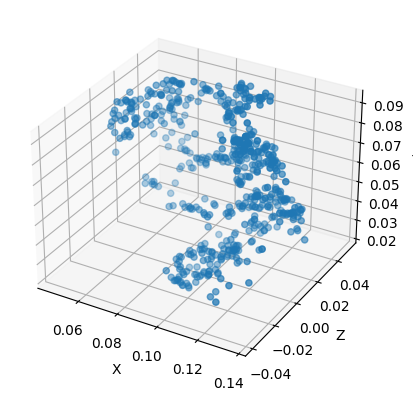

In [53]:
#-------------------------------------------------------------------------------
#                             reconstruct_depth
#-------------------------------------------------------------------------------
def reconstruct_depth(initialPoints, finalPoints, rotationAmount):
    '''
    * initialPoints -  A numpy matrix with the initial values. These values are
                       the (x,y) coordinates for features matched between two
                       images. These coordinates are for the feature in the 
                       first image.
    * finalPoints -    This is similar to the initialPoints, but after the shape
                       has been rotated by some amount.
    * rotationAmount - this is the amount that the points were rotated, in
                       degrees.

    !!! ASSUMPTION:  This assumes perfect rotation along the [0, 1, 0] vector
                     (rotating about the y axis). Future versions of this function
                     should take the axis of rotation into account.
    '''

    #xInitial = (finalPoints - initialPoints * np.cos(rotationAmount * pi/180.0)) / np.sin(rotationAmount * pi/180.0)
    #xFinal = xInitial * np.cos(rotationAmount * pi/180.0) - initialPoints * np.sin(rotationAmount * pi/180.0)

    # Create a set of coordinates fully reconstructed
    #coords = np.hstack((xFinal, finalPoints))


    x1 = initialPoints[:,0]
    y1 = initialPoints[:,1]
    x2 = finalPoints[:,0]
    y2 = finalPoints[:,1]
    theta = rotationAmount * pi / 180.0

    z1 = (x2 - x1 * np.cos(theta)) / np.sin(theta)

    z2 = -x1 * np.sin(theta) + z1 * np.cos(theta)
    
    # invert z2...
    z2 *= -1

    coords = np.hstack((x2, y2, z2))
    #coords = np.hstack((x2, z2, y2))

    return coords


# Reconstruct the depth info given the 5 degree rotation
coords = reconstruct_depth(initialPoints, finalPoints, 5.0)

# Scale down the coordinates (the actual bunny object is of the order 0.01 not 500)
coords /= 5000

df = pd.DataFrame(data=coords.astype(float))
df.columns = ['x', 'y', 'z']
df.to_csv('coords_0deg_5deg.csv', sep=',', header=True, float_format='%.3f', index=False)



# Plot the reconstructed coordinates

fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.scatter(coords[:,0], coords[:,2], coords[:,1])

plt.xlim([0, 800])
plt.ylim([0, 100])
#plt.zlim([0, 640])

ax.set_xlabel('X')
ax.set_ylabel('Z')
ax.set_zlabel('Y')

plt.axis('image')

#plt.show()

# Use Structure from Motion
https://github.com/hsuanhauliu/structure-from-motion-with-OpenCV/blob/master/main.py

In [7]:
print(w, h)

800 600


In [41]:
fov = math.radians(25.0)  # The field of view used to capture the images in opengl
AR = w / h                # The aspect ratio of the viewport (image width / image height)

# Calculate the focal length
f = 1 / math.tan(fov / 2)

# Calculate the optical centers
cx = AR / 2
cy = 0.5

# Create the 3x3 camera matrix
K = np.array([[f, 0, cx],
              [0, f, cy],
              [0, 0, 1]])


# Find the essential matrix
E, mask = cv.findEssentialMat(initialPoints, finalPoints, K, cv.RANSAC, 0.999, 1.0)

matchesMask = mask.ravel().tolist()

draw_params = dict(matchColor = (0,255,0), # draw matches in green color
                    singlePointColor = None,
                    matchesMask = matchesMask, # draw only inliers
                    flags = 2)

#img_inliermatch = cv.drawMatches(pic1, pic1_kp, pic2, pic2_kp, good, None, **draw_params)
#cv.imshow('matches', img_inliermatch)
#cv.waitKey(0)
#cv.destroyAllWindows()

print("Essential matrix:")
print(E)

Essential matrix:
[[-8.31024364e-06  3.60610313e-03 -1.09969402e-01]
 [-3.46224034e-03 -1.20047843e-05 -6.98494612e-01]
 [ 1.04052969e-01  6.99399739e-01  3.95175089e-05]]


# Recover the Pose

In [42]:
### Jon's notes:  it may be possible for us to skip this step since we should know the rotation matrix (unless the camera isn't aligned correctly)

points, R, t, mask = cv.recoverPose(E, initialPoints, finalPoints)
print("Rotation:")
print(R)

print("Translation:")
print(t)

# p1_tmp = np.expand_dims(np.squeeze(p1), 0)
#p1_tmp = np.ones([3, initialPoints.shape[0]])
#p1_tmp[:2,:] = np.squeeze(initialPoints).T
#p2_tmp = np.ones([3, finalPoints.shape[0]])
#p2_tmp[:2,:] = np.squeeze(finalPoints).T
#print((np.dot(R, p2_tmp) + t) - p1_tmp)

Rotation:
[[ 9.99964153e-01  8.46475422e-03  2.02009200e-04]
 [-8.46475939e-03  9.99964173e-01  2.47713825e-05]
 [-2.01792279e-04 -2.64804537e-05  9.99999979e-01]]
Translation:
[[-0.98781954]
 [ 0.15552035]
 [ 0.00509586]]


# Triangulation

In [43]:
#calculate projection matrix for both camera
M_r = np.hstack((R, t))
M_l = np.hstack((np.eye(3, 3), np.zeros((3, 1))))

P_l = np.dot(K,  M_l)
P_r = np.dot(K,  M_r)

# undistort points
#p1 = initialPoints[np.asarray(matchesMask)==1,:]
#p2 = finalPoints[np.asarray(matchesMask)==1,:]

p1 = initialPoints
p2 = initialPoints

p1_un = cv.undistortPoints(p1, K, None)
p2_un = cv.undistortPoints(p2, K, None)
p1_un = np.squeeze(p1_un)
p2_un = np.squeeze(p2_un)

#print(np.shape(initialPoints))
#print(np.shape(finalPoints))
#print(np.shape(p1))
#print(np.shape(p2))
#print(np.shape(p1_un))
#print(np.shape(p2_un))


#triangulate points this requires points in normalized coordinate
point_4d_hom = cv.triangulatePoints(P_l, P_r, p1_un.T, p2_un.T)
point_3d = point_4d_hom / np.tile(point_4d_hom[-1, :], (4, 1))
point_3d = point_3d[:3, :].T

#print(point_4d_hom)

# Plot the result

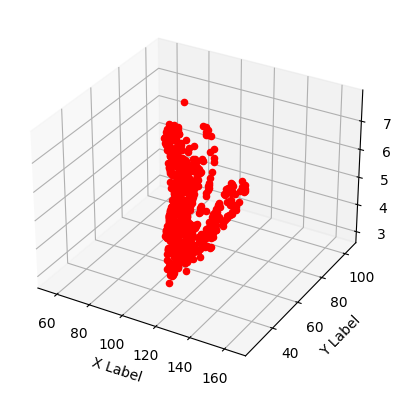

In [46]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.set_xlabel('X Label')
ax.set_ylabel('Y Label')
ax.set_zlabel('Z Label')

for x, y, z in point_3d:
    ax.scatter(x, y, z, c="r", marker="o")

plt.show()